In [ ]:
# ── Notebook parameters ──────────────────────────────────────────────────────

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH   = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# ── Training ─────────────────────────────────────────────────────────────────
TRAIN_DATASET_NAME  = 'plasticc_augment'
CLASSIFIER_NAME     = 'my_mlp_gp'
NUM_EPOCHS          = 100
BATCH_SIZE          = 256
LR                  = 5e-4
AUTO_CLASS_WEIGHTS  = True

HIDDEN_DIMS         = (256, 128, 64)
DROPOUT             = 0.2
USE_BATCH_NORM      = True
STANDARDIZE         = True
LABEL_SMOOTHING     = 0.0
TRACK_FLAT_SCORE    = True

# ── Fold / training settings ─────────────────────────────────────────────────
NUM_FOLDS               = 5
RANDOM_STATE            = 42
VAL_FOLD                = 0
WEIGHT_DECAY            = 1e-4
LR_SCHEDULER_FACTOR     = 0.5
LR_SCHEDULER_PATIENCE   = 3
MIN_LR                  = 1e-6
EARLY_STOPPING_PATIENCE = 20

# ── Precomputed training features ────────────────────────────────────────────
TRAIN_FEATURE_PATH = '/scratch/s4339150/plasticc/features/features_plasticc_augment.h5'
TRAIN_FEATURE_KEY  = 'raw_features'

# ── Prediction ───────────────────────────────────────────────────────────────
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS      = 500
CHUNKS            = range(21)

FEATURE_BASE    = '/scratch/s4339150/plasticc/features/chunks/test/'
FEATURE_PATTERN = 'features_test_chunk_{chunk}_plasticc_test.h5'
FEATURE_KEY     = 'raw_features'

# Output location for per-chunk and combined predictions.
OUT_DIR = 'notebook_outputs/mlp_gp_predictions'

# ── Plot settings ────────────────────────────────────────────────────────────
CONFUSION_NORMALIZE = 'true'
FIGSIZE_HISTORY     = (8, 5)
FIGSIZE_CONFUSION   = (10, 8)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.models import MLPClassifier
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions
from dlip_plasticc.pipelines.predict import predict_partial_from_feature_chunks

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [21]:
config = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(config)

In [22]:
gp_featurizer = avocado.plasticc.PlasticcFeaturizer()

classifier = MLPClassifier(
    name=CLASSIFIER_NAME,
    featurizer=gp_featurizer,
    hidden_dims=HIDDEN_DIMS,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    dropout=DROPOUT,
    auto_class_weights=AUTO_CLASS_WEIGHTS,
    use_batch_norm=USE_BATCH_NORM,
    standardize=STANDARDIZE,
    label_smoothing=LABEL_SMOOTHING,
    track_flat_score=TRACK_FLAT_SCORE,
)

In [23]:
print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME, metadata_only=True)
print(f"Training samples: {len(train_dataset.metadata)}")

Loading training dataset 'plasticc_augment'...
Training samples: 66532


In [24]:
train_feature_path = Path(TRAIN_FEATURE_PATH)

print(f"Inspecting HDF5 keys in: {train_feature_path}")
with pd.HDFStore(train_feature_path, mode="r") as store:
    print(store.keys())

Inspecting HDF5 keys in: /scratch/s4339150/plasticc/features/features_plasticc_augment.h5
['/raw_features']


In [25]:
print("Loading precomputed raw GP features...")
train_raw_features = pd.read_hdf(train_feature_path, key=TRAIN_FEATURE_KEY)

if "object_id" in train_raw_features.columns:
    train_raw_features = train_raw_features.set_index("object_id")

print("Raw feature table shape:", train_raw_features.shape)
display(train_raw_features.head())

Loading precomputed raw GP features...
Raw feature table shape: (66532, 230)


,host_specz,host_photoz,host_photoz_error,ra,decl,mwebv,ddf,count,gp_fit_0,gp_fit_1,...,peaks_neg_lsstr_frac_3,peaks_neg_lssti_count,peaks_neg_lssti_frac_2,peaks_neg_lssti_frac_3,peaks_neg_lsstz_count,peaks_neg_lsstz_frac_2,peaks_neg_lsstz_frac_3,peaks_neg_lssty_count,peaks_neg_lssty_frac_2,peaks_neg_lssty_frac_3
object_id,,,,,,,,,,,,,,,,,,,,,
plasticc_000000615,0.0,0.0,0.0,349.0461,-61.9438,0.017000,True,352,11.133501,0.810587,...,0.986609,19,0.979853,0.944808,20,0.983326,0.979975,25,0.996985,0.992113
plasticc_000000615_aug_LVOEbJnHTA,0.0,0.0,0.0,349.0461,-61.9438,0.018169,False,98,10.642495,0.159404,...,0.948243,15,0.966426,0.889145,17,0.942445,0.891381,18,0.827324,0.824190
plasticc_000000615_aug_NFlmSZYofd,0.0,0.0,0.0,349.0461,-61.9438,0.017042,False,143,10.833813,2.504689,...,0.889738,16,0.730213,0.695306,16,0.631030,0.620007,16,0.928686,0.840662
plasticc_000000615_aug_QDFBWSNCds,0.0,0.0,0.0,349.0461,-61.9438,0.016789,False,108,10.481543,1.857385,...,0.524515,14,0.498239,0.453317,16,0.588691,0.558322,15,0.778549,0.631299
plasticc_000000615_aug_UhfaFwXxsD,0.0,0.0,0.0,349.0461,-61.9438,0.015208,False,144,12.288021,2.438968,...,0.943839,13,0.960159,0.905953,12,0.751887,0.728960,13,0.780721,0.755846


In [26]:
print(f"Training classifier '{CLASSIFIER_NAME}' from precomputed raw features...")
classifier.train(
    train_dataset,
    raw_features=train_raw_features,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")
print(f"Validation fold: {classifier.val_fold}")
print("Detected classes:", classifier.class_names)
print("Input dim:", classifier.input_dim)

Training classifier 'my_mlp_gp' from precomputed raw features...


Epochs:   1%|          | 1/100 [00:01<01:51,  1.12s/it]

Epoch 1  train=1.81915  train_acc=0.3604  val=1.12239  val_acc=0.5234  lr=5.00e-04


Epochs:   2%|▏         | 2/100 [00:02<01:50,  1.13s/it]

Epoch 2  train=1.13661  train_acc=0.5287  val=0.91910  val_acc=0.6316  lr=5.00e-04


...

Epoch 76  train=0.54382  train_acc=0.7375  val=0.62763  val_acc=0.7493  lr=1.00e-06


Epochs:  77%|███████▋  | 77/100 [01:27<00:26,  1.17s/it]

Epoch 77  train=0.54460  train_acc=0.7365  val=0.62523  val_acc=0.7508  lr=1.00e-06


Epochs:  77%|███████▋  | 77/100 [01:28<00:26,  1.16s/it]

Epoch 78  train=0.54384  train_acc=0.7359  val=0.62724  val_acc=0.7532  lr=1.00e-06
Early stopping at epoch 78.  Best val=0.62458
Best validation loss: 0.62458
Best validation loss: 0.62458
Validation fold: 0
Detected classes: [ 6 15 16 42 52 53 62 64 65 67 88 90 92 95]
Input dim: 41


In [27]:
history_df = classifier.history.copy()
display(history_df.tail())

,epoch,train_loss,train_acc,val_loss,val_acc,lr,val_flat_score
73,74,0.541968,0.737825,0.626217,0.750916,0.000001,NaN
74,75,0.544275,0.735549,0.625932,0.747999,0.000001,NaN
75,76,0.543820,0.737468,0.627632,0.749346,0.000001,NaN
76,77,0.544596,0.736452,0.625230,0.750841,0.000001,NaN
77,78,0.543837,0.735944,0.627245,0.753160,0.000001,NaN


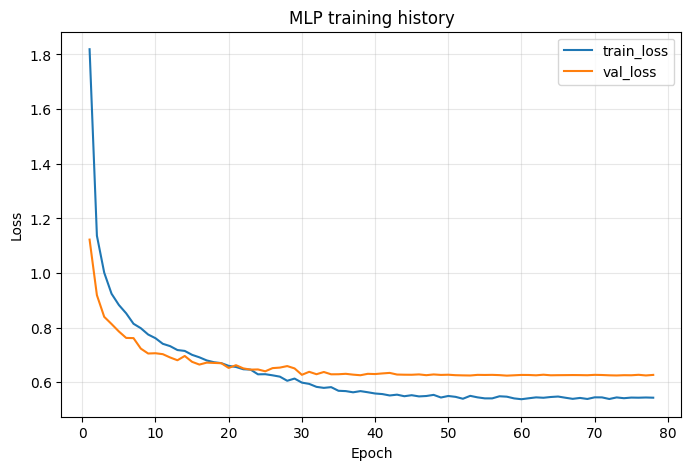

In [28]:
plt.figure(figsize=FIGSIZE_HISTORY)
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP training history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
# ── Test-set prediction ───────────────────────────────────────────────────────

from pathlib import Path
import os

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

print(f"Predicting on test dataset '{TEST_DATASET_NAME}'...")
test_predictions, processed_chunks = predict_partial_from_feature_chunks(
    classifier=classifier,
    dataset_name=TEST_DATASET_NAME,
    total_chunks=TOTAL_CHUNKS,
    chunks=CHUNKS,
    feature_base=FEATURE_BASE,
    feature_pattern=FEATURE_PATTERN,
    feature_key=FEATURE_KEY,
    out_dir=OUT_DIR,
    show_progress=True,
)

Predicting on test dataset 'plasticc_test'...


Chunks: 100%|██████████| 21/21 [00:03<00:00,  5.63it/s]


In [30]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, test_predictions)
print(f'Flat-weighted log-loss: {flat_score:.5f}')
print(f'Objects scored:         {n_scored:,}')

Flat-weighted log-loss: 0.65741
Objects scored:         146,085


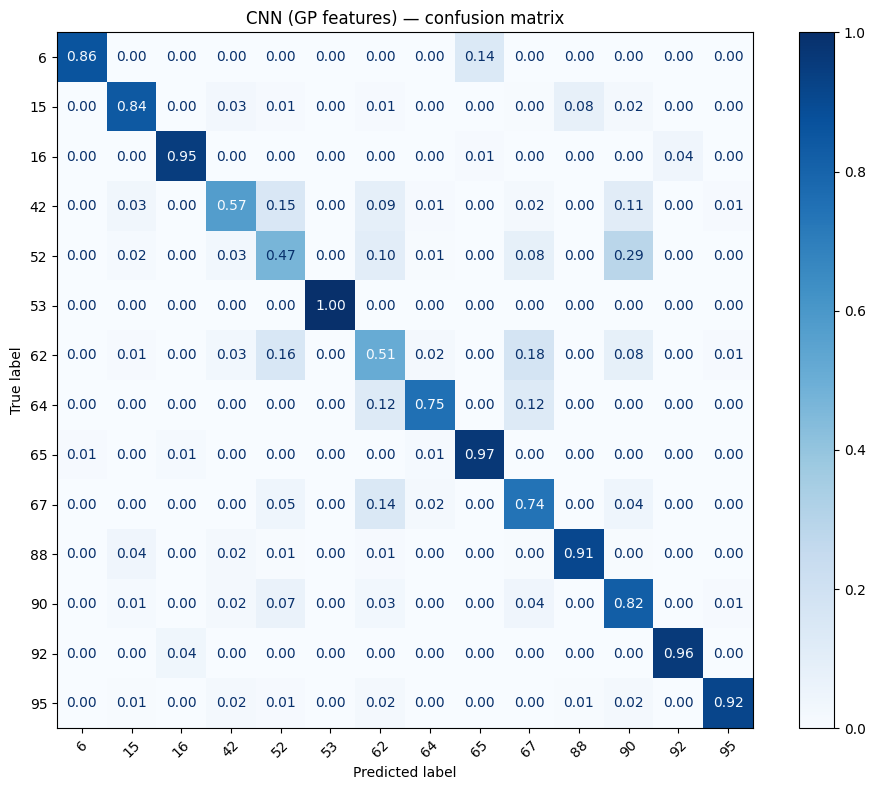

In [18]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    test_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred  = pred_aligned.idxmax(axis=1)
labels  = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True,
          cmap=plt.cm.Blues, values_format='.2f')
ax.set_title('CNN (GP features) — confusion matrix')
plt.tight_layout()
plt.show()